## Introducción

Como analista de datos, tu objetivo es **evaluar cómo la movilidad urbana se relaciona con la productividad económica en las principales ciudades latinoamericanas**. 
Para ello trabajarás con datos reales de TomTom Traffic Index y OECD Cities, que deberás limpiar, combinar y analizar para identificar en qué ciudades conviene invertir en infraestructura de transporte.

## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de ambos datasets**.
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯Objetivo:**
Importar las librerías necesarias, cargar los archivos CSV en DataFrames y realizar una revisión preliminar para entender su contenido.

**Instrucciones:**
- Importa las librerías `pandas`, `numpy`, `seaborn` y `matplotlib.pyplot`.
- Carga los archivos usando `pd.read_csv()`:
  - `'/datasets/tomtom_traffic.csv'`
  - `/datasets/oecd_city_economy.csv` `.
- Guarda los DataFrames en las variables `traffic` y `eco`.
- Muestra las primeras 5 filas de cada DataFrame.


In [2]:
# Aquí traemos las liberías necesarias para el proyecto
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
# cargar archivos
traffic = pd.read_csv('/datasets/tomtom_traffic.csv')
eco =     pd.read_csv('/datasets/oecd_city_economy.csv')

In [4]:
# vamos a revisar los encabezados de la información para familiarizarnos la información de l tráfico
traffic.head()

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232
3,ARE,abu-dhabi,2025-01-13 01:46:30.001,8.2,2.0,4.1,2.0,2.0,2025-01-06 01:46:30.000,7.723808,7.899046,-0.175238
4,ARE,abu-dhabi,2025-01-13 00:01:30.000,1.1,1.0,0.2,1.0,1.0,2025-01-06 00:01:30.000,8.336363,8.604379,-0.268016


In [5]:
# revisamos los encabezados e información acerca de la economía
eco.head()

,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"
3,2023,brasilia,Brazil,"15.999,00",8.3%,"13,50","4,70"
4,2023,salvador,Brazil,"8.761,00",13.1%,"16,00","3,90"


**Tip:** Si no usas `print()` la tabla se vera mejor.


---

## 🧩Paso 2: Explorar, limpiar y preparar los datos

Antes de combinar los datasets, inspecciona su estructura, tipos de datos, columnas y valores faltantes.
Anota las columnas que necesiten limpieza y luego estandariza los nombres de columnas.

### 2.1 Explorar la estructura y tipos de datos

**🎯Objetivo:**
Identificar columnas con tipos incorrectos, distribución y nulos, anotar las columnas que requieren conversión.

**Instrucciones:**

- Usa `.info()` para conocer la estructura de ambos DataFrames.
- Muestra los primeros 3 renglones de cada DF.
- Identifica si los detalles de cada DF estan bien o si requieren correcciones y escribe tus conclusiones en el bloque Markdown.
  - ¿Hay columnas que requieren conversión?¿ Cuáles son? ¿Que tipo de dato ienen y cuál deberían de tener?
  - ¿Hay datos ausentes en alguna columna?


In [6]:
# Vamos a revisar las columnas y tipos de datos para hacer correcciones, de igual manera vamos a trraer las primeras tres filas para checar contra el tipo de datos
traffic.info()
traffic.head(3)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   Country                         1004464 non-null  object 
 1   City                            1004464 non-null  object 
 2   UpdateTimeUTC                   1004464 non-null  object 
 3   JamsDelay                       1004464 non-null  float64
 4   TrafficIndexLive                1004464 non-null  float64
 5   JamsLengthInKms                 1004464 non-null  float64
 6   JamsCount                       1004464 non-null  float64
 7   TrafficIndexWeekAgo             1004464 non-null  float64
 8   UpdateTimeUTCWeekAgo            1004464 non-null  object 
 9   TravelTimeLivePer10KmsMins      1004464 non-null  float64
 10  TravelTimeHistoricPer10KmsMins  1004464 non-null  float64
 11  MinsDelay                       1004464 non-null  float64
dtype

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232


En la estructura del DF traffic, se observa que:
- Las columnas `UpdateTimeUTC` y `UpdateTimeUTC` son de tipo objeto y deben cambiar a datatime

- 
- ...

In [7]:
# Examinar la estructura de eco, vamos a revisar las columnas y tipos de datos para hacer correcciones, de igual manera vamos a trraer las primeras tres filas para checar contra el tipo de datos
eco.info()
eco.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Year             30 non-null     int64 
 1   City             30 non-null     object
 2   Country          30 non-null     object
 3   City GDP/capita  30 non-null     object
 4   Unemployment %   30 non-null     object
 5   PM2.5 (μg/m³)    30 non-null     object
 6   Population (M)   30 non-null     object
dtypes: int64(1), object(6)
memory usage: 1.8+ KB


,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"


En la estructura del DF eco, se observa que:
- Las columnas `City GDP/capita`, `Unemployment %`, PM2.5 y Population son de tipo objeto y hay que cambiarlas a float64
- ... 

### 2.2 Renombrar columnas

**🎯Objetivo:**
Estandarizar los nombres de columnas para evitar errores y facilitar la unión de los datasets.

**Instrucciones:**

- Cambia los nombres de las columnas para que tengan el formato `snake_case`.
    - `Country` → `country`
    - `UpdateTimeUTC` → `update_time_utc`
- Verifica que los cambios se hayan aplicado correctamente usando `.columns`.


In [8]:


# Estandarizar los nombres de las columnas de traffic
#Vamos a convertir los datos a minisculas y eliminar los espacios de los encabezados (columnas)
traffic.columns= traffic.columns.str.lower().str.strip()
# Aquí realizamos ajustes que fueron necesarios para hacer coincidir las columnas contra el código que encontré más adente en el proyecto
traffic = traffic.rename(columns = {"updatetimeutc" : "update_time_utc", "updatetimeutcweekago":"update_time_utc_week_ago"} )
traffic = traffic.rename(columns = {"jamsdelay" : "jams_delay", "trafficindexlive":"traffic_index_live",  "jamslengthinkms" : "jams_length_kms" ,"jamscount": "jams_count", "minsdelay" : "mins_delay"} )
traffic = traffic.rename(columns = {"traveltimeliveper10kmsmins" : "travel_time_live_per_10kms_mins", "traveltimehistoricper10kmsmins":"travel_time_hist_per_10kms_mins",  } )
# verificar cambios
traffic.columns



Index(['country', 'city', 'update_time_utc', 'jams_delay',
       'traffic_index_live', 'jams_length_kms', 'jams_count',
       'trafficindexweekago', 'update_time_utc_week_ago',
       'travel_time_live_per_10kms_mins', 'travel_time_hist_per_10kms_mins',
       'mins_delay'],
      dtype='object')

In [9]:
# Estandarizar los nombres de las columnas de eco
#Vamos a convertir los datos a minisculas y eliminar los espacios de los encabezados (columnas)
eco.columns = eco.columns.str.lower().str.strip()
# #Vamos a convertir los datos a minisculas y eliminar los espacios de los encabezados (columnas)amos a cambiar el nombre de las columnas para que coincidan con el proyecto
eco = eco.rename(columns = {"city gdp/capita" : "city_gdp_capita", "unemployment %":"unemployment_pct", "population (m)":"population_m", "pm2.5 (μg/m³)": "pm25"} )

# verificar cambios
eco.columns

Index(['year', 'city', 'country', 'city_gdp_capita', 'unemployment_pct',
       'pm25', 'population_m'],
      dtype='object')


### 2.3 Corregir formatos numéricos y de fecha

**🎯Objetivo:**
Asegurar que las columnas de fechas y valores numéricos estén en formatos correctos para permitir análisis, cálculos y comparaciones precisas.

**Instrucciones:**

- Convierte las columnas de fecha de `traffic` a formato `datetime`. Haz el cambio a prueba de errores.
- En el dataset `eco`, limpia los valores numéricos:
    - En `city_gdp_capita`: elimina separadores de miles (`.`) y reemplaza las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
    - En `unemployment_pct`: elimina el símbolo de porcentaje (`%`) y reemplaza las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
    - En `population_m`: reemplaza las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
- Finalmente, crea una nueva columna llamada `population` multiplicando `population_m` por 1,000,000 para obtener la población total.


<details>
<summary>Haz clic para ver la pista</summary>
para eliminar símbolos, puedes reemplazarlos por un texto vacío.

In [10]:
# Convertir las columnas de traffic a tipo fecha con pd.to_datetime()
# Convertimos esas columnas a datetime y protegemos contra errorres
traffic['update_time_utc'] =          pd.to_datetime (traffic['update_time_utc'], errors = "coerce")
traffic['update_time_utc_week_ago'] = pd.to_datetime (traffic['update_time_utc_week_ago'], errors = "coerce")
# verificar el cambio
traffic.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                           Non-Null Count    Dtype         
---  ------                           --------------    -----         
 0   country                          1004464 non-null  object        
 1   city                             1004464 non-null  object        
 2   update_time_utc                  1004464 non-null  datetime64[ns]
 3   jams_delay                       1004464 non-null  float64       
 4   traffic_index_live               1004464 non-null  float64       
 5   jams_length_kms                  1004464 non-null  float64       
 6   jams_count                       1004464 non-null  float64       
 7   trafficindexweekago              1004464 non-null  float64       
 8   update_time_utc_week_ago         1004464 non-null  datetime64[ns]
 9   travel_time_live_per_10kms_mins  1004464 non-null  float64       
 10  travel_time_hist_per_10kms_min

In [11]:
# Limpia separadores y convierte columnas numéricas en eco
#eco['city_gdp_capita'] = ....astype(str).str.replace('.', '').str.replace(',', '.').astype(float)
eco['city_gdp_capita'] = eco['city_gdp_capita'].astype(str).str.replace('.', '').str.replace(',', '.').astype(float)
eco['unemployment_pct']= eco['unemployment_pct'].astype(str).str.replace('%', '').astype(float)
eco['population_m'] =    eco['population_m'].astype(str).str.replace('.', '').str.replace(',', '.').astype(float)

# Calcula la población total en unidades absolutas (Multiplica * 1000000)
# eco['population'] = ...
eco['population'] = eco['population_m'] * 1000000
# verificar el cambio
eco.info()
eco.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              30 non-null     int64  
 1   city              30 non-null     object 
 2   country           30 non-null     object 
 3   city_gdp_capita   30 non-null     float64
 4   unemployment_pct  30 non-null     float64
 5   pm25              30 non-null     object 
 6   population_m      30 non-null     float64
 7   population        30 non-null     float64
dtypes: float64(4), int64(1), object(3)
memory usage: 2.0+ KB


,year,city,country,city_gdp_capita,unemployment_pct,pm25,population_m,population
0,2023,buenos-aires,Argentina,15782.0,6.2,"15,2",15.3,15300000.0
1,2023,sao-paulo,Brazil,14475.0,9.1,"29,50",22.5,22500000.0
2,2023,rio-de-janeiro,Brazil,13142.0,9.8,"19,10",13.6,13600000.0



---

## 🧩Paso 3: Extraer año y filtrar

Extraer el año permite filtrar la información y trabajar solo con el período más reciente y relevante.

### 3.1 Extraer columna año y filtrar 2024

**🎯Objetivo**
Identificar el año de cada registro y mantener solo los registros del 2024.

**Intrucciones**

- Como el DataFrame `traffic` no tiene una columna de año, utiliza el atributo `.dt.year` sobre su columna de fecha para crear una nueva columna llamada `year`.
- Filtra las filas donde el año sea **2024**.
- Utiliza `.copy()` para crear dos nuevos DataFrames (`traffic_2024` y `eco_2024`) para evitar modificar el dataset original.

In [12]:
# Extraer el año de las fechas en update_time_utc
traffic['year'] = traffic["update_time_utc"].dt.year

#Utiliza .copy() para crear dos nuevos DataFrames (traffic_2024 y eco_2024) para evitar modificar el dataset original.
traffic_2024 = traffic[traffic["year"] == 2024]
# Verificar cambio
traffic_2024.head(3)

,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_kms,jams_count,trafficindexweekago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins,mins_delay,year
302,ARE,abu-dhabi,2024-12-31 23:01:30,12.9,5.0,2.5,5.0,2.0,2024-12-24 23:01:30.001,8.560399,8.519634,0.040765,2024
303,ARE,abu-dhabi,2024-12-31 22:01:30,136.0,21.0,20.6,32.0,3.0,2024-12-24 22:01:30.000,10.355732,9.049445,1.306286,2024
304,ARE,abu-dhabi,2024-12-31 21:16:30,455.2,31.0,40.4,72.0,4.0,2024-12-24 21:01:30.000,11.456878,9.305174,2.151704,2024


In [13]:
# Filtra los registros del año 2024
eco_2024 = eco[eco["year"]==2024].copy()
# Revisar dataframes nuevos
eco_2024.head()


,year,city,country,city_gdp_capita,unemployment_pct,pm25,population_m,population
15,2024,buenos-aires,Argentina,18117.0,7.2,"14,50",15.4,15400000.0
16,2024,sao-paulo,Brazil,14703.0,8.5,"28,00",22.6,22600000.0
17,2024,rio-de-janeiro,Brazil,13349.0,9.2,"18,40",13.7,13700000.0
18,2024,brasilia,Brazil,16251.0,7.8,"12,80",4.8,4800000.0
19,2024,salvador,Brazil,8899.0,12.4,"15,20",3.9,3900000.0



---

## 🧩Paso 4: Analizar y resumir datos de movilidad

Como el dataset de tráfico contiene **múltiples registros por ciudad**. En esta parte, calcularás los promedios anuales por ciudad para simplificar el análisis y obtener una visión más clara de las tendencias generales.

### 4.1 Calcular promedios de tráfico por ciudad

**🎯Objetivo:**
Obtener una vista consolidada del tráfico promedio por ciudad y año, para analizar patrones generales sin depender de datos diarios.

**Instrucciones**

- Agrupa los datos por `city`, `country` y `year`.
- Calcula el promedio **solo de las métricas de tráfico más relevantes**: como `jams_delay`, `traffic_index_live`, `jams_length_kms`, `jams_count`, `mins_delay`, y tiempos de viaje (`travel_time_live_per_10kms_mins` y `travel_time_hist_per_10kms_mins`).
- Guarda el resultado como `traffic_city_year_2024`, mantén las columnas como variables (no índices).


<details>
<summary>Haz clic para ver la pista</summary>
Usa ".agg()" para aplicar funciones de promedio. Al final, reinicia el índice para mantener las columnas de la agrupación como variables (no índices).

In [17]:
# Calcular los  promedios de trafico por ciudad, país y año
traffic_city_year_2024 = traffic_2024.groupby(["city", "country", "year"]).agg({
    "jams_delay": "mean", 
    "traffic_index_live": "mean", 
    "jams_length_kms": "mean", 
    "jams_count": "mean", 
    "mins_delay": "mean", 
    "travel_time_live_per_10kms_mins": "mean", 
    "travel_time_hist_per_10kms_mins": "mean"
}).reset_index()

# Mostrar resultado
traffic_city_year_2024.head()

,city,country,year,jams_delay,traffic_index_live,jams_length_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins
0,a-coruna,ESP,2024,17.935187,15.259774,2.198002,4.934405,0.774172,16.267977,15.493804
1,aachen,DEU,2024,26.732141,20.960314,3.892586,6.601832,0.792968,13.397861,12.604894
2,aarhus,DNK,2024,21.200616,16.575891,2.736736,6.109987,0.495276,15.219292,14.724016
3,abu-dhabi,ARE,2024,171.157315,13.902028,24.507380,47.268019,0.139764,9.829092,9.689328
4,adana,TUR,2024,83.864761,22.541040,11.827331,23.754620,1.129749,15.879694,14.749945


### 🧠 **Momento de reflexión**

¡Excelente trabajo hasta aquí!

Ahora que ya tienes los promedios anuales por ciudad, es momento de **observarlos** con atención.

Piensa:

- ¿Cuál crees que tiene el mayor tiempo promedio de tráfico?
- ¿Será una ciudad de **Europa**, de **Latinoamérica** o de **otra región** del mundo?

Para descubrirlo, ejecuta esta línea de código:

`traffic_city_year_2024.sort_values(["jams_delay"], ascending=False)`


🔍 Observa qué ciudad aparece en los primeros lugares.

¿Te sorprenden los resultados? , ¿Coinciden con lo que imaginabas?

In [29]:
traffic_city_year_2024.sort_values(["jams_delay"], ascending = False)
#print(type(traffic_city_year_2024))
#print(traffic_city_year_2024.shape)
# vamos a ver los paises diferentes
#print (traffic_city_year_2024["city"].nunique())


,city,country,year,jams_delay,traffic_index_live,jams_length_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins
221,mexico-city,MEX,2024,2833.057892,34.218190,389.239265,594.969392,1.855542,21.809092,19.953550
352,tokyo,JPN,2024,2152.574357,36.805059,373.069734,518.809420,0.698152,22.443778,21.745626
246,new-york,USA,2024,2133.400000,28.210388,398.227892,544.474902,1.396351,18.505043,17.108691
200,london,GBR,2024,2050.703662,29.230166,287.632868,471.795554,1.325160,17.714139,16.388979
211,manila,PHL,2024,1741.493381,66.129402,246.858082,341.881205,2.469894,27.134629,24.664734
...,...,...,...,...,...,...,...,...,...,...
111,dunedin,NZL,2024,4.651175,15.430809,0.712315,1.591384,0.633294,16.226009,15.592715
363,uppsala,SWE,2024,4.194486,13.939168,0.656368,1.349672,0.501802,15.746717,15.244916
123,fujairah,ARE,2024,4.025959,10.907719,0.731910,1.373006,0.194951,11.662590,11.467639
12,almere,NLD,2024,3.633523,6.290478,0.506362,1.064063,-0.017544,9.467150,9.484694


La ciudad con el mayor tiempo promedio de tráfico es ...  México city


---

## 🧩Paso 5: Unir movilidad y economía

Combinar datasets te permite analizar cómo se relacionan los indicadores económicos con los de movilidad.

### 5.1 Unir tráfico (tabla principal) con indicadores económicos

**🎯Objetivo:**
Combinar la información de tráfico y economía en un solo DataFrame para analizar cómo las condiciones económicas se relacionan con la movilidad urbana.

**Instrucciones**
- Selecciona solo las **columnas relevantes** de cada dataset (por ejemplo, variables clave de tráfico y de economía).
- Usa `.copy()` al crear subconjuntos para evitar modificar el dataset original.
- Une ambos DataFrames y define como **claves de unión** a `city` y `year`.
- Mantén solo las ciudades y años presentes en ambos datasets.
- Guarda el resultado en una nueva variable llamada `merged` y muestra las primeras 5 filas.


<details>
<summary>Haz clic para ver la pista</summary>
Aplica una unión de tipo "inner" para mantener las ciudades y años presentes en ambos datasets.

In [30]:
# Seleccionar columnas clave de tráfico y economía
left_cols = ['city','country','year','jams_delay','traffic_index_live',
             'jams_length_kms','jams_count','mins_delay',
             'travel_time_live_per_10kms_mins','travel_time_hist_per_10kms_mins']

right_cols = ['city','year','city_gdp_capita','unemployment_pct','pm25','population']

# Usar .copy() para crear los dos nuevos datasets reducidos
traffic_2024_small = traffic_city_year_2024[left_cols].copy()
eco_2024_small = eco_2024[right_cols].copy()

#eco_2024_small.head()
#traffic_2024_small.head()

# Unir datasets
merged = pd.merge(traffic_2024_small,eco_2024_small, on = ["city","year"], how = "inner")
# Mostrar las primeras 5 filas
#merged.head()
# Vamos a modificar el orden de las columnas para mayor facilidad de la interpretación de los datos
merged = merged[['city','country','city_gdp_capita','jams_delay','traffic_index_live',
             'jams_length_kms','jams_count','mins_delay',
             'travel_time_live_per_10kms_mins','travel_time_hist_per_10kms_mins',
              'unemployment_pct','pm25','population', 'year']]

# vamos a ordenaros los datos de a cuerdo a su PIB para analizar los resultados
merged.sort_values(["city_gdp_capita"], ascending = False)
# ahora vamos a analizar de acuerdo a los tiempos de restraso

merged.sort_values(["jams_delay"], ascending = False)


,city,country,city_gdp_capita,jams_delay,traffic_index_live,jams_length_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins,unemployment_pct,pm25,population,year
7,mexico-city,MEX,21111.0,2833.057892,34.218190,389.239265,594.969392,1.855542,21.809092,19.953550,3.2,"22,30",22100000.0,2024
14,sao-paulo,BRA,14703.0,1729.189270,26.877932,238.419896,431.470460,1.129026,20.801836,19.672810,8.5,"28,00",22600000.0,2024
1,bogota,COL,11442.0,1141.552364,37.614273,140.893564,230.566550,1.699628,24.992185,23.292557,10.0,"17,60",11300000.0,2024
6,lima,PER,13472.0,1052.292789,31.031277,110.314770,213.453519,1.506305,25.674261,24.167956,6.5,"19,70",11200000.0,2024
13,santiago,CHL,2277.0,629.865318,20.155352,93.489121,153.095300,0.627445,17.031310,16.403864,7.8,"21,30",7100000.0,2024
3,buenos-aires,ARG,18117.0,571.089593,17.756012,100.287844,137.359860,0.416566,17.907916,17.491349,7.2,"14,50",15400000.0,2024
11,rio-de-janeiro,BRA,13349.0,466.064706,25.162963,85.015120,123.891939,0.361302,17.137320,16.776018,9.2,"18,40",13700000.0,2024
0,belo-horizonte,BRA,11124.0,263.047879,19.428946,44.038129,68.805422,0.487228,18.304538,17.817311,9.5,"16,80",6100000.0,2024
4,curitiba,BRA,12381.0,183.469274,14.954545,30.050044,46.898164,0.139965,17.258700,17.118736,8.2,"13,50",3700000.0,2024
9,porto-alegre,BRA,11801.0,139.382830,17.687254,20.167849,39.813403,0.194195,16.166684,15.972490,8.7,"14,20",4300000.0,2024



---

## 🧩Paso 6: Visualización y análisis de relaciones

Ahora que tienes un dataset limpio y unificado, es momento de **visualizar patrones**.
Los gráficos te ayudarán a entender cómo se relacionan las variables económicas con las de movilidad urbana.

### 6.1 Visualizar relaciones entre economía y tráfico

**🎯Objetivo:**
Analizar visualmente la distribución y la relación entre indicadores de tráfico y economía en 2024, para identificar posibles patrones o tendencias generales entre ambas variables.

**Instrucciones**
- Usa las librerías `seaborn` y `matplotlib.pyplot` para generar los gráficos.
- Visualiza la distribución del **tráfico** (`jams_delay`) mediante:
    - **Boxplot** → para observar la media, mediana y detectar valores atípicos.
- Visualiza la distribución de la **economía** (`city_gdp_capita`) mediante:
    - **Histograma** → para analizar la forma de la distribución y el valor promedio del PIB per cápita.
- Finalmente, **compara ambas variables**, para observar si existe alguna relación entre ellas, haciendo un solo gráfico de barras donde aparezcan ambos indicadores.
- Recuerda agregar título y etiquetas a los ejes de tus gráficos.
- Observa y comenta los patrones, valores extremos o posibles relaciones que identifiques.

**Tip:** Dentro de los parentesis del boxplot, agrega `showmeans=True` para ver la media en el gráfico.

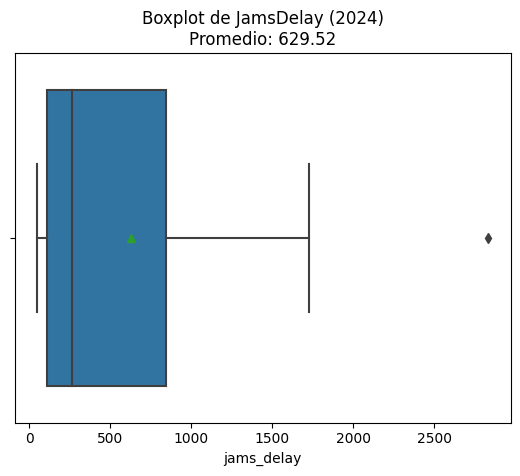

In [28]:
# Crear boxplot para observar el comportamiento de los minutos de congestion JamsDelay
# crea tu gráfico
sns.boxplot (data = merged , x = "jams_delay" , showmeans = True)
# obtener promedio para mostrarlo en título
mean_value = merged['jams_delay'].mean()
plt.title(f'Boxplot de JamsDelay (2024)\nPromedio: {mean_value:.2f}')
plt.show()


# vamos a revisar los valores que están fuera de rango
#merged.sort_values(["jams_delay"], ascending = False)
# Los valores que se ven fuera de rango es la cd de México y la siguiente es Brasil así que parecen estar bien.


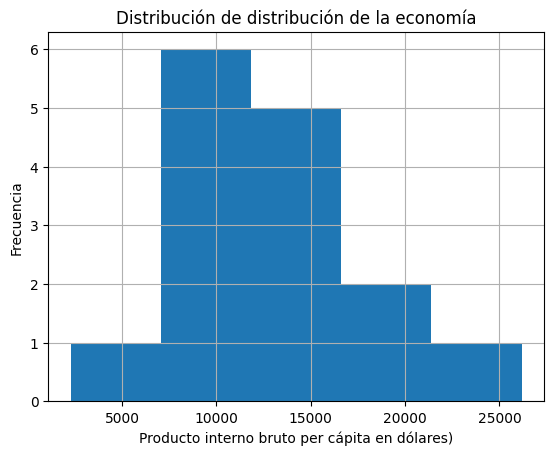

,city,country,city_gdp_capita,jams_delay,traffic_index_live,jams_length_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins,unemployment_pct,pm25,population,year
8,montevideo,URY,26176.0,50.201092,17.014854,6.369201,14.160332,0.393442,18.892342,18.498900,8.4,"11,20",1800000.0,2024
7,mexico-city,MEX,21111.0,2833.057892,34.218190,389.239265,594.969392,1.855542,21.809092,19.953550,3.2,"22,30",22100000.0,2024
3,buenos-aires,ARG,18117.0,571.089593,17.756012,100.287844,137.359860,0.416566,17.907916,17.491349,7.2,"14,50",15400000.0,2024
2,brasilia,BRA,16251.0,101.576326,11.258220,18.337133,27.280140,0.193442,13.338658,13.145216,7.8,"12,80",4800000.0,2024
14,sao-paulo,BRA,14703.0,1729.189270,26.877932,238.419896,431.470460,1.129026,20.801836,19.672810,8.5,"28,00",22600000.0,2024
6,lima,PER,13472.0,1052.292789,31.031277,110.314770,213.453519,1.506305,25.674261,24.167956,6.5,"19,70",11200000.0,2024
11,rio-de-janeiro,BRA,13349.0,466.064706,25.162963,85.015120,123.891939,0.361302,17.137320,16.776018,9.2,"18,40",13700000.0,2024
4,curitiba,BRA,12381.0,183.469274,14.954545,30.050044,46.898164,0.139965,17.258700,17.118736,8.2,"13,50",3700000.0,2024
9,porto-alegre,BRA,11801.0,139.382830,17.687254,20.167849,39.813403,0.194195,16.166684,15.972490,8.7,"14,20",4300000.0,2024
1,bogota,COL,11442.0,1141.552364,37.614273,140.893564,230.566550,1.699628,24.992185,23.292557,10.0,"17,60",11300000.0,2024


In [35]:


# Crear histograma para ver la distribución de la economía (city_gdp_capita)
merged["city_gdp_capita"].hist(bins =5)
plt.title('Distribución de distribución de la economía')

plt.xlabel('Producto interno bruto per cápita en dólares)')
plt.ylabel('Frecuencia')
plt.show()
merged.sort_values(["city_gdp_capita"], ascending = False)



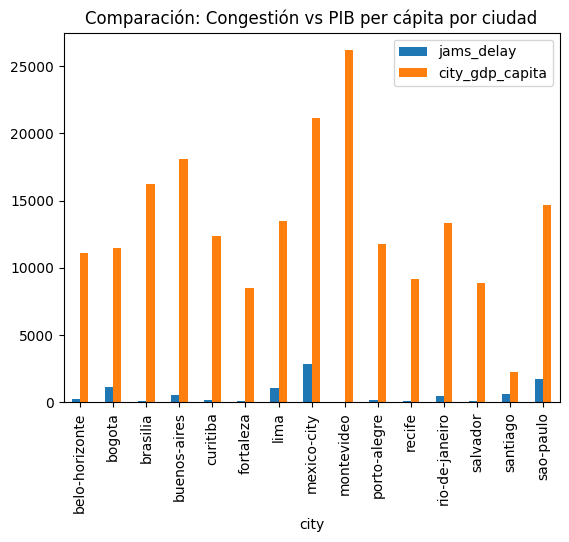

In [30]:
# Gráfico de barras para comparar jams_delay y city_gdp_capita por ciudad
#merged.plot( ... , y=['jams_delay', 'city_gdp_capita'])

merged.plot(x='city', y=['jams_delay', 'city_gdp_capita'], kind='bar')
plt.xticks(rotation=90)
plt.title('Comparación: Congestión vs PIB per cápita por ciudad')
plt.show()

In [32]:
# vamos a revisar porque montevideo nos aparece con mayor gdp 
#revisar_m = merged[merged["city"].str.contains("montevideo")]
#revisar_m.head()
#revisar_uruguay = eco_2024_small[eco_2024_small["city"].str.contains("montevideo")]
#revisar_uruguay.head()
#revisar =  eco_2024[eco_2024["city"].str.contains("montevideo")]
#revisar.head()
#revi = eco[eco["city"].str.contains("montevideo")]
#revi.head()
 #city_gdp_capita
#revisar_m.sort_values(["city_gdp_capita"], ascending = False)
## Vemos que los datos son consistentes con el año 2023, gogleando encontre que Uruguay es considerado el país con mayor PIB per cápita de Latinoamérica en 2026, con un estimado de más de U$S 26,000 por habitante 

**Tip:** Antes del `plt.show()` agrega el código `plt.xticks(rotation=90)` para rotar las etiquetas del eje X en 90 grados.

In [31]:
#merged.sort_values(["city_gdp_capita"], ascending = True)  # mexico brasil bogota lima
#merged.sort_values(["jams_delay"], ascending = False) # mexico sao pablo bogota lima
merged.sort_values(by = ["city_gdp_capita", "jams_delay"], ascending = [False, False] )

,city,country,city_gdp_capita,jams_delay,traffic_index_live,jams_length_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins,unemployment_pct,pm25,population,year
8,montevideo,URY,26176.0,50.201092,17.014854,6.369201,14.160332,0.393442,18.892342,18.498900,8.4,"11,20",1800000.0,2024
7,mexico-city,MEX,21111.0,2833.057892,34.218190,389.239265,594.969392,1.855542,21.809092,19.953550,3.2,"22,30",22100000.0,2024
3,buenos-aires,ARG,18117.0,571.089593,17.756012,100.287844,137.359860,0.416566,17.907916,17.491349,7.2,"14,50",15400000.0,2024
2,brasilia,BRA,16251.0,101.576326,11.258220,18.337133,27.280140,0.193442,13.338658,13.145216,7.8,"12,80",4800000.0,2024
14,sao-paulo,BRA,14703.0,1729.189270,26.877932,238.419896,431.470460,1.129026,20.801836,19.672810,8.5,"28,00",22600000.0,2024
6,lima,PER,13472.0,1052.292789,31.031277,110.314770,213.453519,1.506305,25.674261,24.167956,6.5,"19,70",11200000.0,2024
11,rio-de-janeiro,BRA,13349.0,466.064706,25.162963,85.015120,123.891939,0.361302,17.137320,16.776018,9.2,"18,40",13700000.0,2024
4,curitiba,BRA,12381.0,183.469274,14.954545,30.050044,46.898164,0.139965,17.258700,17.118736,8.2,"13,50",3700000.0,2024
9,porto-alegre,BRA,11801.0,139.382830,17.687254,20.167849,39.813403,0.194195,16.166684,15.972490,8.7,"14,20",4300000.0,2024
1,bogota,COL,11442.0,1141.552364,37.614273,140.893564,230.566550,1.699628,24.992185,23.292557,10.0,"17,60",11300000.0,2024


### 🧠 **Reflexiona**
Excelente trabajo llegando a esta etapa del análisis. Antes de avanzar, revisa tus gráficos, tómate un momento para pensar:

* ¿Las ciudades con mayor PIB per cápita también presentan más congestión?

* ¿O sucede lo contrario, o no existe una relación clara?

# ¿Ciudades con mayor PIB per capita también presentan más congestión? No.
# Montevideo aparece con el mayor PIB ($26,126) y su tiempo de restraso (Jams delay) aparece de  50 minutos por lo que tiene bajos niveles de congestión y es el país con mejor PIB.
# Buenos aires y Brasilia aparecen con un mayor PIB que lima por ejemplo que los supera por mucho en tiempos de restraso.




---

## 🧩Paso 7: Exportar y documentar resultados

En esta etapa final consolidarás todo tu trabajo: guardarás el dataset limpio y crearás un resumen que documente los resultados del proyecto.

### 7.1 Guardar dataset final

**🎯Objetivo:**
Generar un CSV limpio, reproducible y con columnas relevantes para análisis posterior.

**Instrucciones**

- Exporta el DataFrame `merged` con el nombre: `ladb_mobility_economy_2024_clean.csv`
- Usa `index=False` para no incluir el índice.


In [27]:
# Exporta el dataset final como CSV
merged.to_csv("ladb_mobility_economy_2024_clean.csv", index=False)



Para poder ver o descargar el archivo generado:   
En el menú lateral que esta a la izquierda, ve hasta la parte de abajo, a la sección de **Exportar dataset** para más información. 




---

## ✅ Entregables

1. **Notebook `.ipynb`** con todas las celdas (código + comentarios).
2. **CSV final**: `ladb_mobility_economy_2024_clean.csv`.
3. **Resumen ejecutivo breve** en Markdown (3–5 párrafos).



---

# 🧾 Resumen ejecutivo (plantilla)

> Completa este resumen al finalizar el análisis. Mantén 3–5 párrafos cortos, claros y accionables.

**Contexto & objetivo:**  
- * ¿Qué relación existe entre la movilidad urbana (congestión, tiempos de viaje) y la productividad económica (PIB per cápita)?
- Una mayor congestión de tráfico tiende a asociarse con menores niveles de PIB per Cápita en la mayoría de los casos, pero encontramos sus excepciones significativas.


- * Explica brevemente las variables clave utilizadas y su relevancia para la toma de decisiones.
- Para realizar este análisis se utilizó los datos de país, ciudad, año,
- city_gdp_capita: Producto Interno Bruto per cápita en dólares (USD). Refleja el nivel de productividad económica por habitante
- jams_delay: Retraso total (en minutos) provocado por la congestión en todas las vías monitoreadas.
- Así como otras variables significativas como: mins_delay y jams_count, pero no se considerarón como indicadores principales, sin embargo fueron considerados como aportadores de información para en análisis.

**Cobertura de datos:**  
- * Especifica los años analizados, número de ciudades y países incluidos.
- Se analizó el año 2024 que contenía información de 15 ciudades y 7 países.

**Metodología (alto nivel):**  
- * Describe los procesos principales: limpieza de datos (formatos, estandarización de columnas).
- * Explica la agregación por ciudad–año y el uso de una unión INNER para integrar tráfico y economía.
- * Menciona las validaciones visuales empleadas (distribuciones, outliers, tendencias generales).

- Se utilizaron los archivos fuentes de tomtom_traffic.csv  que contiene datos sobre congestión vehicular y condiciones de tráfico,  además del archivo de oecd_city_economy.csv que contiene indicadores económicos y ambientales por ciudad y fue recopilado por la OECD ((Organización para la Cooperación y el Desarrollo Económico)).
- Se estandarizaron los nombres de las columnas en ambos archivos para que no contuvieran espacios ni caracteres especiales.
- Se cambió en tomtom_traffic las columnas de update_time_utc y update_time_utc_week_ago a tipo fecha.
- Se transformó el tipo de datos a numerico o float de las columnas que requerían cálculos como la medía por ejemplo la columna de city_gdp_capita, unemployment_pct, etc.
- Se agregó una columna a los datos de tomtom_traffic que contiene el año de la información, el año se estrajo de la columna update_time_utc.
- Se agrupó en la información de tomtom_traffic por ciudad, país y año agregando la medía para las columnas de:  "jams_delay", "traffic_index_live", "jams_length_kms", "jams_count", "mins_delay", 
    "travel_time_live_per_10kms_mins", "travel_time_hist_per_10kms_mins".
- Se dejaron sólo las columnas que erán importantes y se unificaron en un solo archivo final que contiene solo la información del año 2024 , para hacer esta integración se utilizó un inner join para integrar tráfico y economía, utilizando como llave el país la cíudad y el año.
- Se realizaron 3 tipos de gráficas:
- Boxplot de JamsDelay (2024) en dónde nos indica un valor muy alejado de la medía, por lo que se procedió a analizar de donde venía ese dato y se llegó a la conslusión de que era correcto ya que procede de la información del tráfico de la cd de México para en año 2024.
- Se creó el gráfico de barras de la distribución de la economía en donde vemos los resultamos más alejados de la medía que son de la ciudad de México y Montevideo, por lo que se procedió a validar que la información de Montevideo fuera la correcta, se conluyó que si era de esta manera ya que antes de filtrar el año 2024 en nuestro Dataframe encontramos valores muy parecidos para en año 2023.
- Se graficó la congestión vs PIB per cápita para el año 2024 en donde podemos ver claramente la distribución de ambas en donde podemos ver más claramente la relación entre ambos indicadores, aquí podemos ver un alto índice de tráfico en Lima, Bógota, Rio de Janeiro y San Pablo y un PIB per capita más cercano a la medía (gráfico de barras de la distribución de la economía).
- 


**Hallazgos iniciales:**  
- * Resume los patrones más importantes entre índices de tráfico y PIB per cápita.
- Hay una relación clara entre mayores niveles de congestión de tráfico y el PIB de las ciudades.
- 
- * Destaca anomalías u outliers que podrían requerir revisión adicional o un análisis más profundo.
- Cómo anomalías tenemos a cd de México con un PIB de $21,111.00, sin embargo el tiempo de retraso (jams_delay) de 2,833 minutos.
- También tenemos a Montevide con un PIB de $26,176.00 y un tiempo de retraso considerablemente pequeño de 50 minutos (considerablemente más pequeño que en la cd de México con un PIB cercano)
- Los minutos de restraso en estás dos ciudades que tienen los dos resultados de productividad económica más altos serían: México city con 1.85 minutos de retraso y Montevideo con 0.39 minutos de retraso, hay una considerable difencia entre los anteriores por lo cúal podemos concluir de ser cierta la aseveración de que entre mayor productividad económica mayor tiempos de restraso, estariamos observando resultados similarmente altos para ambas ciudades, pero son diametralmente opuestos, pero también podemos observar que estás son dos excepciones que merecen un análisis puntual de cómo se generaron las condiciones que llevaron a estos resultados que salen de la cotidianidad.
- Si analizamos traffic_index, nos encontramos también que Montevideo cuenta con un promedio de 17 en una escala de clasificación del (1 al 100)  con un índice de tráfico actual y la cd de México con una calificación de 34 para el mismo indicador osea el doble remarcando que su valor pér Cápita es muy cercano.
- De la misma manera si analizamos los embotellamientos (jams_count) tenemos a Montevideo con un total de embotellamientos activos de 14 eventos y la Ciudad de México con 594 para este indicador.

**Recomendaciones**  
Aterriza los hallazgos en acciones: ciudades prioritarias, necesidad de validar fuentes, requerimiento de análisis adicionales, o propuestas de inversión.
- Por lo anterior se sugiere que se invierta en infraestructura en las ciudades con mayor nivel de tráfico y retrasos deberían ser prioritarías y se impulse de manera consecuente la productividad y crecimiento económico, asi como tomar acciones en los casos excepcionales (CD de México y Santiago)
- Las principales ciudades que tendrían que tomar acciones para prevenir los tiempos de retraso serían Sao Pablo, Bógota, Lima y Santiago.
- Como caso extremo tenemos a Santiago en donde tenemos una alta congestión de trafico y menor nivel de productividad económica, por lo que se sugiere tomar medidas contigentes urgentes.
- Sugerimos realizar acciones correctivas en la cd de México, invertir en infraestrctura que permita una mejor movilidad de la población, podríamos ver de esta manera mejoras significativas en su PIB pér capíta.


- ¿Qué ciudad : Bogotá, Lima o Buenos Aires o alguna otra en particular, muestra la mayor correlación significativa entre altos niveles de congestión vehicular y bajos indicadores de productividad económica, sugiriendo ser una ciudad prioritaria para inversión en infraestructura de transporte?
- Santiago de chile muestra un nivel de retraso de 629 minutos (5to lugar con peor tiempo de retraso de todos los analizados) con el índice per cápita más bajo de $ 2,277.0
- Bogota, lima y Buenos aires de ecnontrarían dentro de la medía en cuanto a ingresos per cápita aunque con valores altos en tiempos de retraso.


In [36]:


# Vamos a verificar el número de ciudades y paises analizados
#print(merged["city"].nunique())
#print(merged["country"].nunique())




15
7
